In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~ /content/drive/MyDrive/kaggle.json
!kaggle competitions download -c playground-series-s5e3
!unzip /content/playground-series-s5e3.zip
!pip install bayesian-optimization
!pip install optuna

  0% 0.00/59.0k [00:00<?, ?B/s]
100% 59.0k/59.0k [00:00<00:00, 767kB/s]
Archive:  /content/playground-series-s5e3.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.9 MB/s eta 0:00:00


In [ ]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 53.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [ ]:
!pip uninstall catboost numpy -y
!pip install catboost==1.2.2 numpy==1.26.0

Found existing installation: catboost 1.2.7
Uninstalling catboost-1.2.7:
  Successfully uninstalled catboost-1.2.7
Found existing installation: numpy 1.24.0
Uninstalling numpy-1.24.0:
  Successfully uninstalled numpy-1.24.0
  Using cached catboost-1.2.2-cp311-cp311-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached numpy-1.26.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached catboost-1.2.2-cp311-cp311-manylinux2014_x86_64.whl (98.7 MB)
Using cached numpy-1.26.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import catboost
from sklearn.model_selection import cross_val_score

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

In [ ]:
train_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [ ]:
train_data.describe()

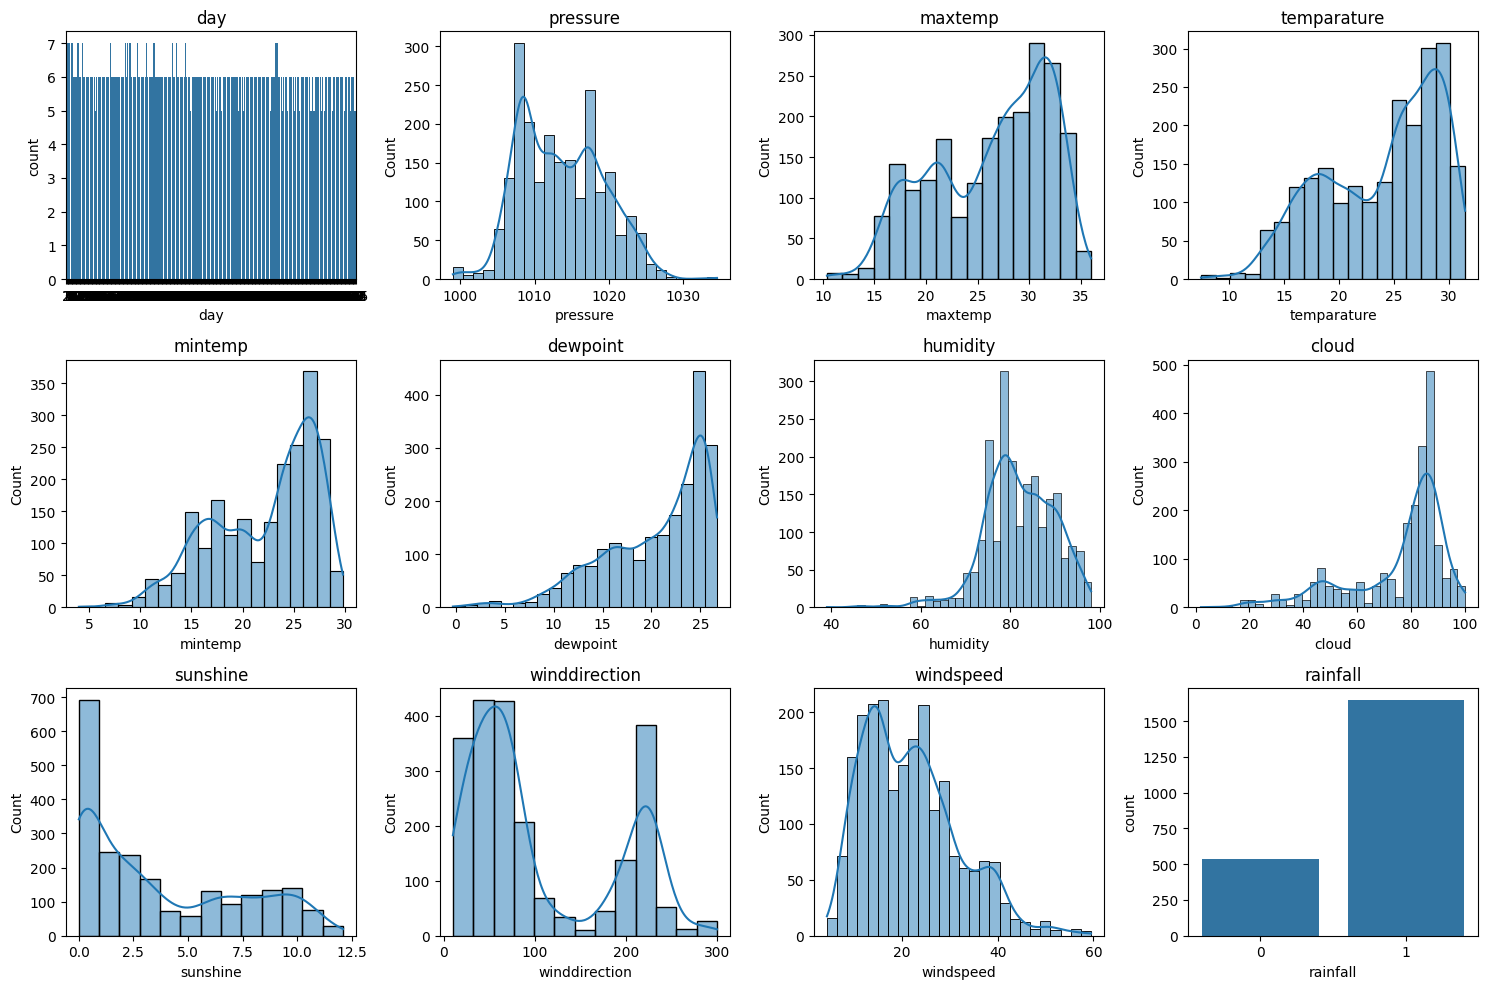

In [ ]:
plt.subplots(3, 4, figsize=(15,10))

for i, col in enumerate(train_data.columns[1:]):
  plt.subplot(3, 4, i+1)
  plt.title(col)
  if  train_data[col].dtype == 'float64':
    sns.histplot(train_data[col], kde=True)

  else:
    sns.countplot(x = col , data = train_data)

plt.tight_layout()
plt.show()

# **Here are The Insights Derived From The Hist & Count Plots**


**Day:** The distribution of 'day' appears uniform, indicating consistent data collection across all days.

**Pressure:** The pressure values are concentrated around 1010–1020 hPa, showing a slightly skewed distribution with fewer occurrences at extreme values.

**Max Temperature:** Maximum temperature mostly ranges between 25°C and 35°C, with a peak around 30°C.

**Temperature:** The overall temperature distribution mirrors the max temperature, peaking near 30°C, suggesting stable climatic conditions.

**Min Temperature:** Minimum temperatures are concentrated between 20°C and 30°C, with a notable peak around 25°C.

**Dew Point:** Dew point values are mostly distributed between 10°C and 25°C, peaking near 25°C, indicating moderate humidity levels.

**Humidity:** Humidity is heavily skewed towards higher values, clustering around 80–100%, indicating a predominantly humid environment.

**Cloud Cover:** Cloud cover is concentrated near 80–100%, showing frequent overcast conditions.

**Sunshine:** Sunshine hours are skewed towards lower values, with most days having less than 5 hours of sunshine, suggesting cloudy weather.

**Wind Direction:** Wind direction shows a bimodal distribution with peaks around 100° and 300°, indicating dominant wind patterns from specific directions.

**Wind Speed:** Wind speeds are distributed mostly between 0 and 40 km/h, peaking near lower speeds, suggesting calm to moderate wind conditions.

**Rainfall:** Rainfall is binary (0 or 1), with more instances of rainfall recorded (1), indicating frequent precipitation in the dataset.

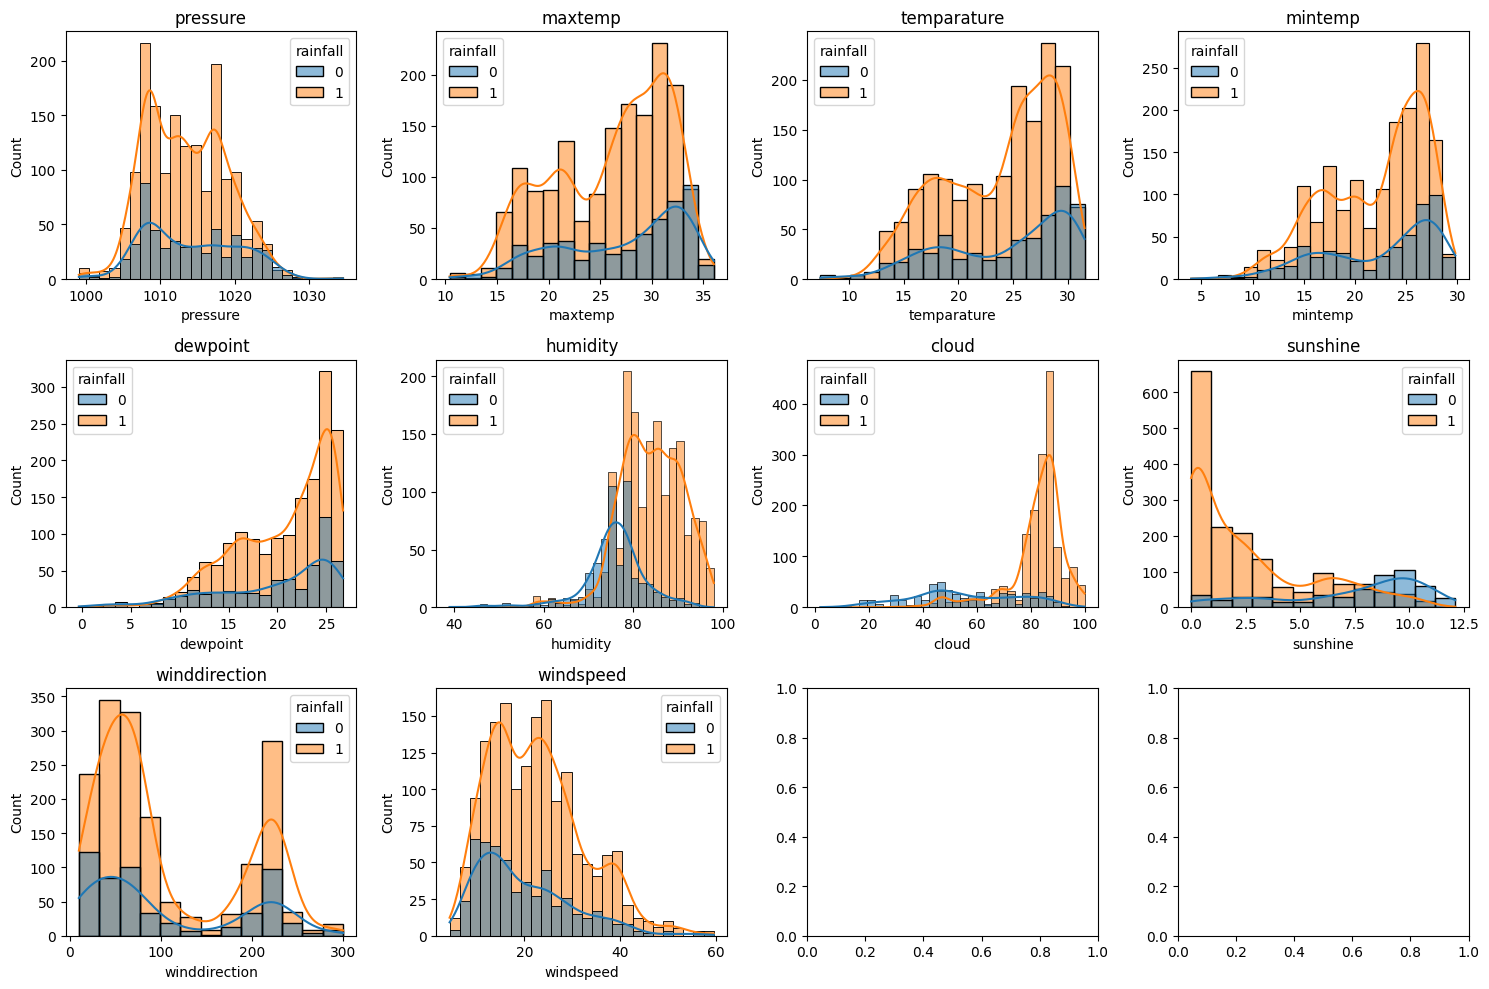

In [ ]:
plt.subplots(3, 4, figsize=(15,10))

for i, col in enumerate(train_data.columns[2:-1]):
  plt.subplot(3, 4, i+1)
  plt.title(col)
  if  train_data[col].dtype == 'float64':
    sns.histplot(x=train_data[col], hue= train_data.rainfall, kde=True)

  else:
    sns.countplot(x = col ,data = train_data, hue='rainfall')

plt.tight_layout()
plt.show()

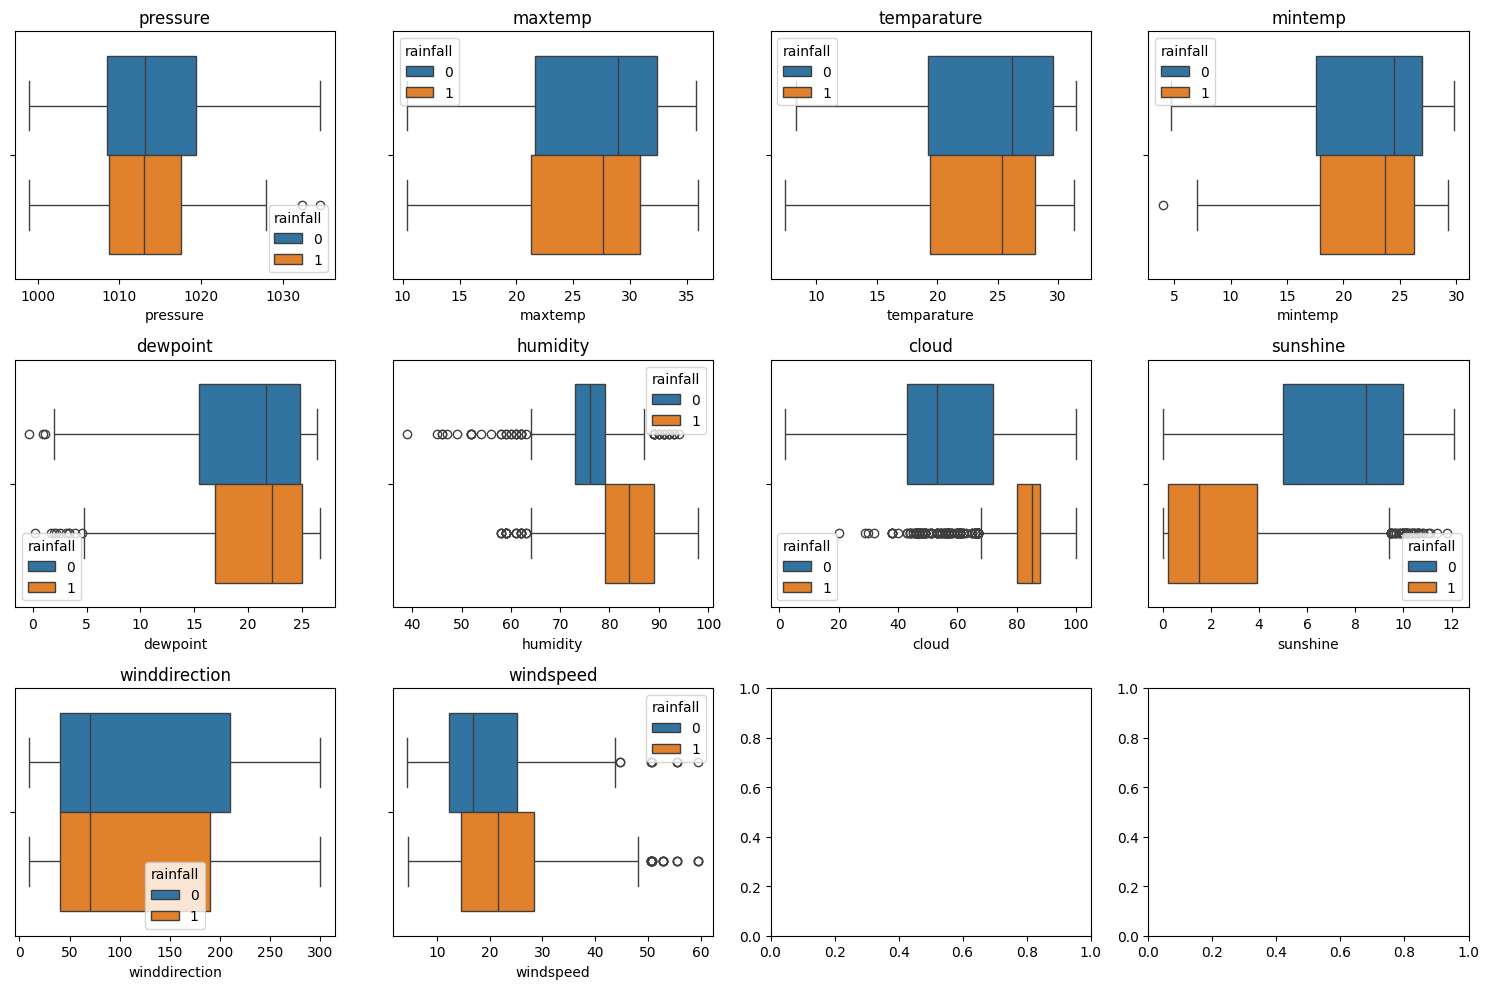

In [ ]:
plt.subplots(3, 4, figsize=(15,10))

for i, col in enumerate(train_data.columns[2:-1]):
  plt.subplot(3, 4, i+1)
  plt.title(col)
  sns.boxplot(x=train_data[col], hue= train_data.rainfall)

plt.tight_layout()
plt.show()

# **Here are The Insights Derived From The Hist & Box Plots**

**Pressure:**

* Rainfall (1) is more frequent at lower pressure values, primarily between 1005
and 1015 hPa.

* Non-rainfall (0) events are distributed across a slightly higher pressure range, peaking near 1015–1020 hPa.

**Max Temperature:**

* Rainfall events are more common when the maximum temperature is between 25°C and 30°C.

* Non-rainfall events dominate at higher maximum temperatures, especially above 30°C.

**Temperature:**

* Rainfall is concentrated around temperatures of 25°C–30°C.

* Non-rainfall events occur more frequently at slightly lower temperatures, around 20°C–25°C.

**Min Temperature:**

* Rainfall is most frequent when the minimum temperature is between 20°C and 25°C.

* Non-rainfall events have a broader spread but peak near similar temperature ranges.

**Dew Point:**

* Higher dew points (above 20°C) strongly correlate with rainfall events.

* Non-rainfall events are more common at lower dew points (below 15°C).

**Humidity:**

* Rainfall occurs predominantly at high humidity levels (80%–100%).

* Non-rainfall events are more evenly distributed across lower humidity levels (40%–80%).

**Cloud Cover:**

* Rainfall is strongly associated with high cloud cover (80%–100%).

* Non-rainfall events occur more frequently under lower cloud cover conditions.

**Sunshine:**

* Rainfall is most frequent when sunshine hours are minimal (0–2 hours).

* Non-rainfall events increase as sunshine duration rises, particularly above 5 hours.

**Wind Direction:**

* Rainfall events show peaks in specific wind directions, particularly around 100° and 200°.

* Non-rainfall events are spread across a wider range of wind directions but peak near similar values.

**Wind Speed:**

* Rainfall occurs more frequently at moderate wind speeds (10–30 km/h).

* Non-rainfall events dominate at very low wind speeds (<10 km/h) and higher speeds (>40 km/h).



In [ ]:
train_data.head()

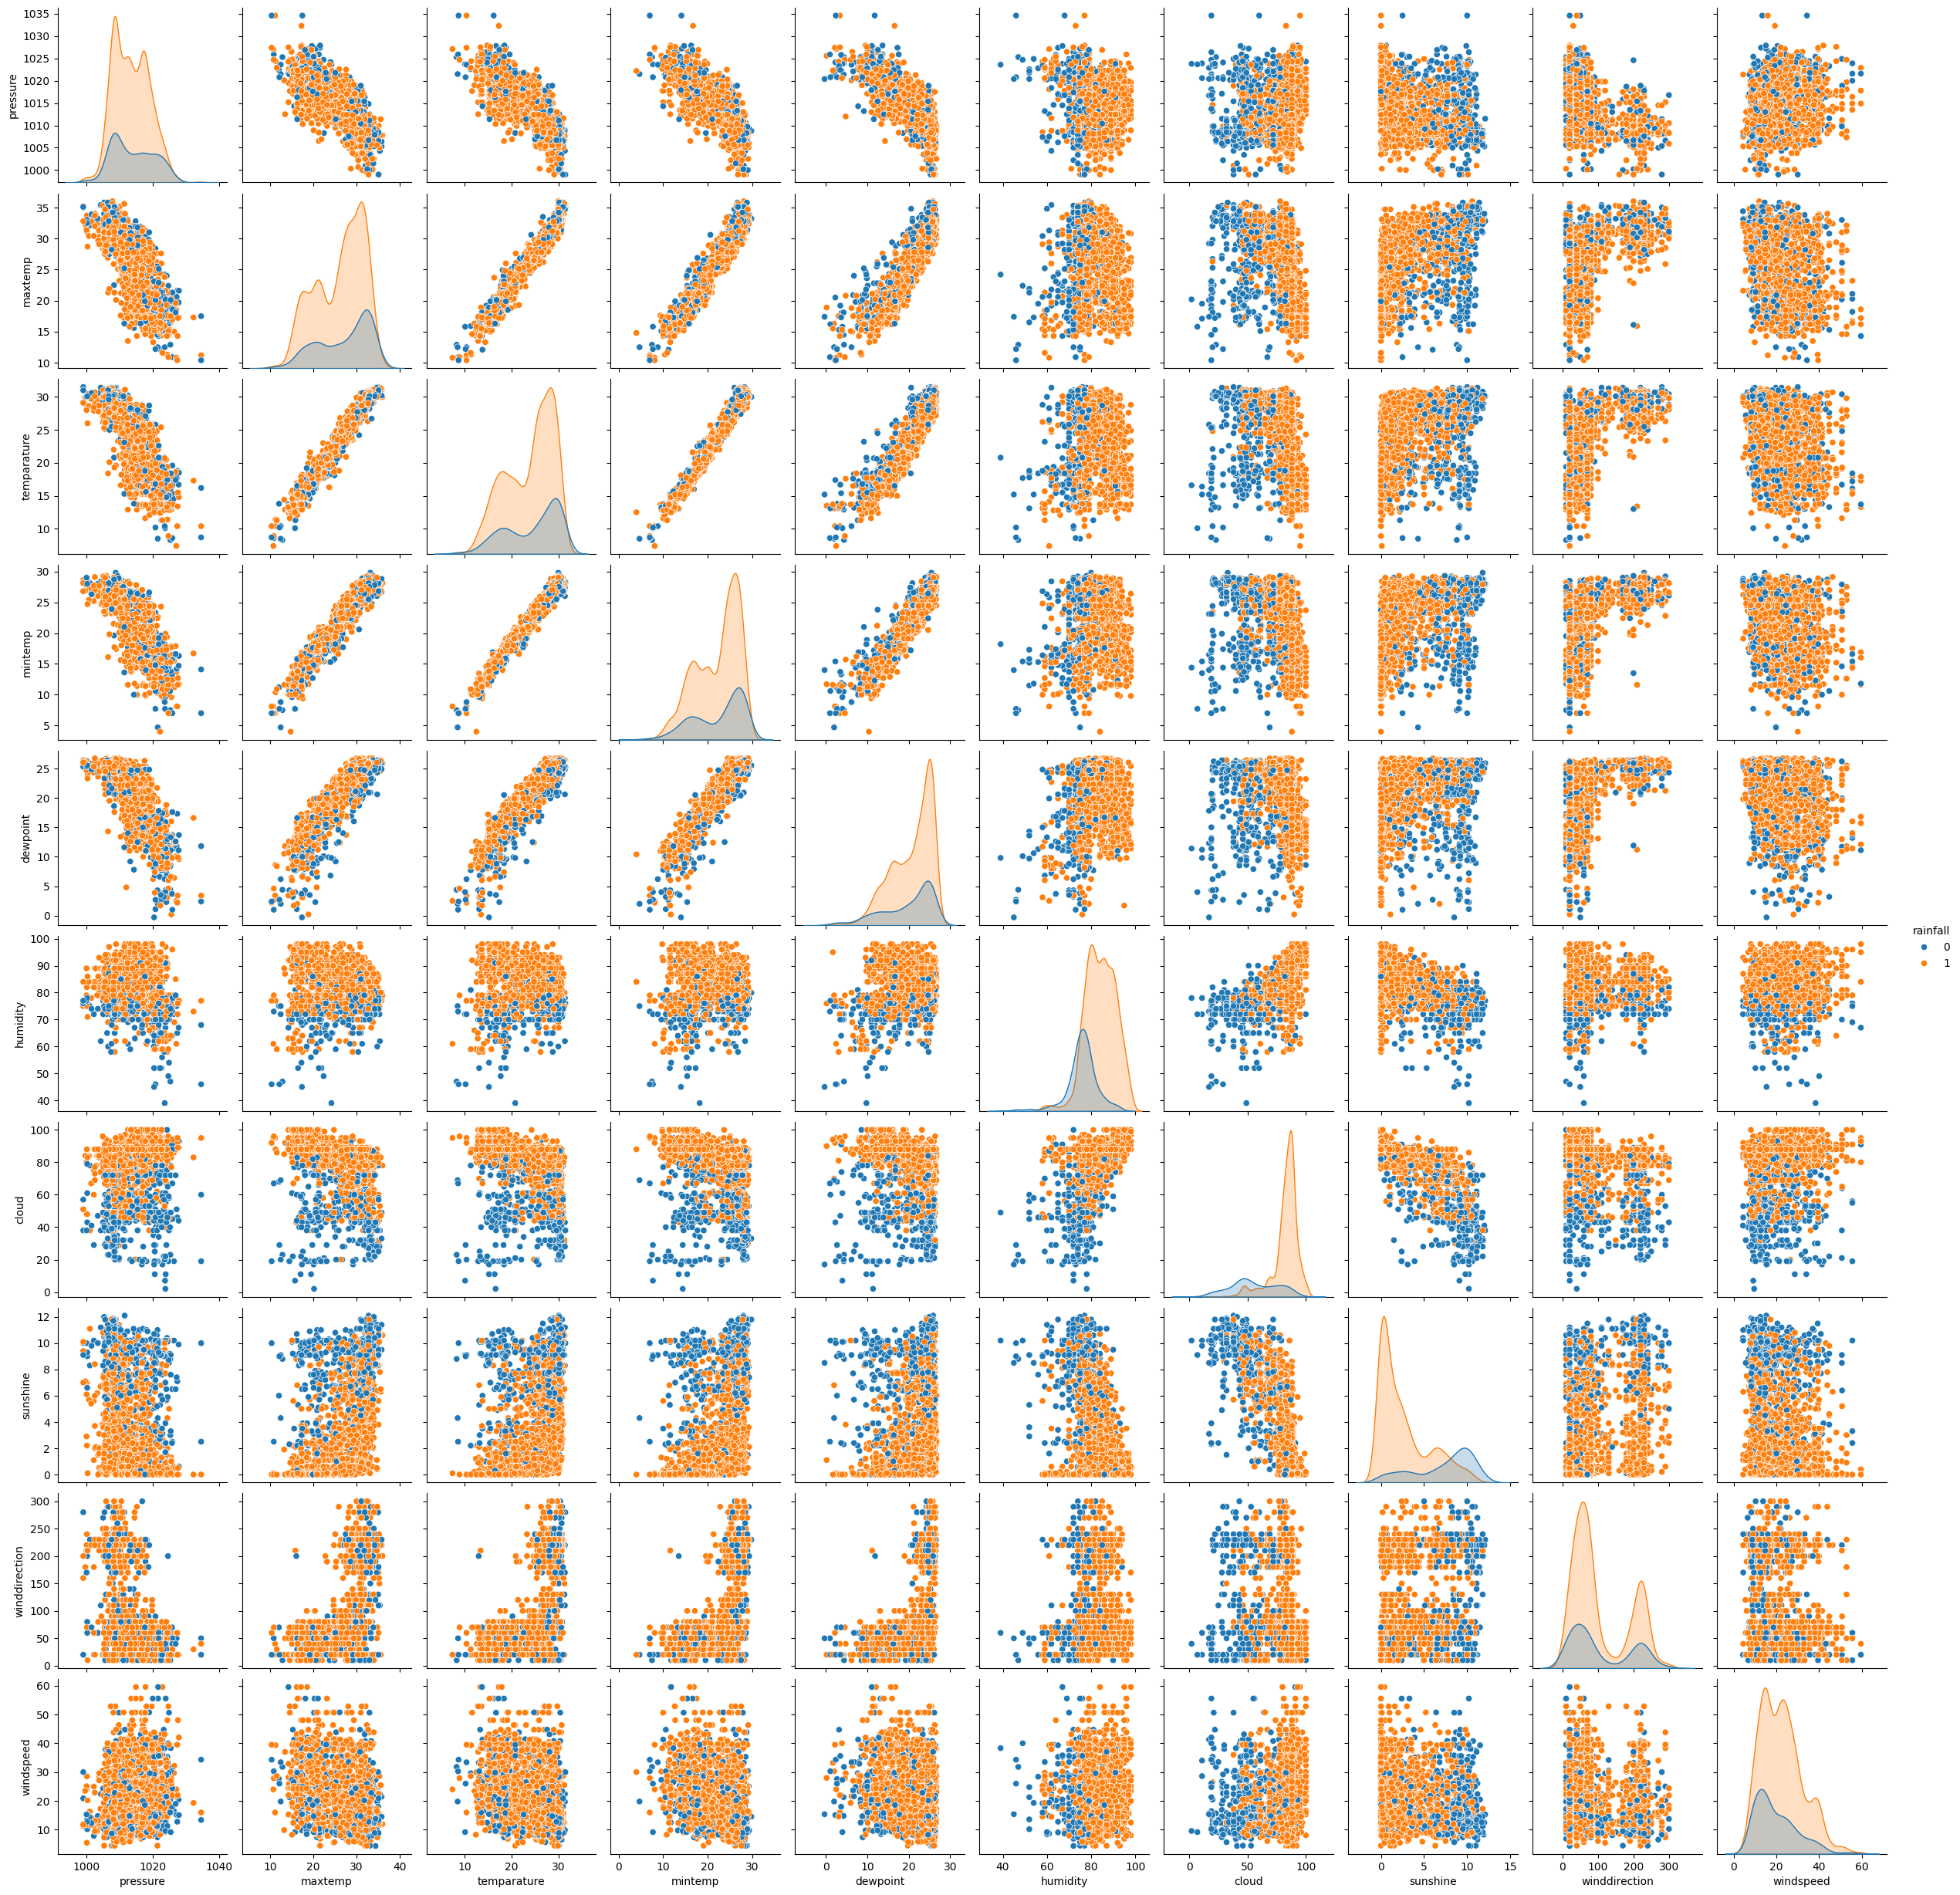

In [ ]:
sns.pairplot(train_data[train_data.columns[2:]], hue='rainfall')
plt.show()

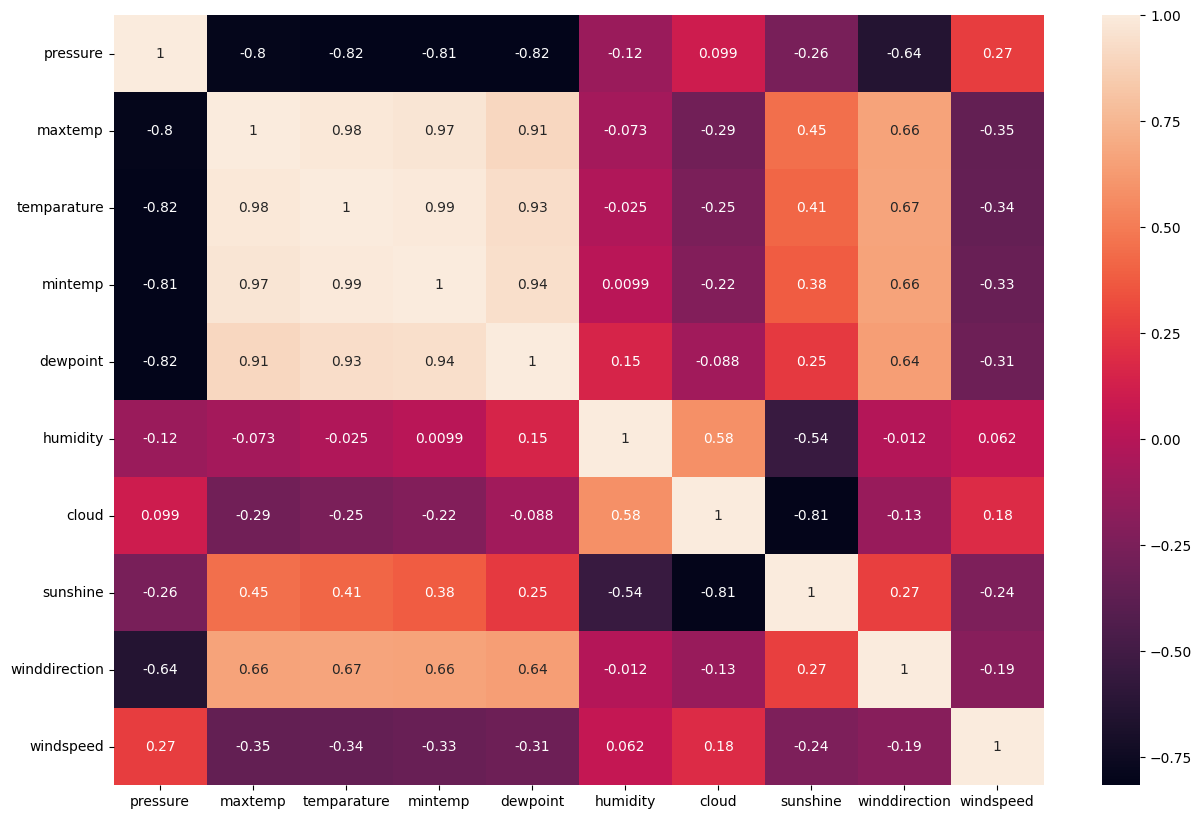

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(train_data[train_data.columns[2:-1]].corr(), annot=True)
plt.show()

1. **Temperature Variables** **(maxtemp, temparature, mintemp)** are highly correlated with each other (0.97-0.99). This is expected as these variables naturally move together.

2. **Pressure** is negatively correlated with **temperature** variables and dewpoint (-0.80 to -0.82). Lower pressure means higher temperatures and dew point.

3. **Cloud cover** and **sunshine** have a strong negative correlation (-0.81). More clouds significantly reduce sunshine.

4. **Humidity** and **cloud cover** have a moderate positive correlation (0.58). Higher humidity often coincides with increased cloudiness.

5. **Wind Direction** has a moderate correlation with **temperature** variables(0.66-0.67) and a strong negative correlation with pressure(-0.64). Certain wind directions are associated with warmer temperatures and lower pressure.

In [ ]:
train_data['sin_day'] = np.sin(2 * np.pi * train_data['day'] / 365)
train_data['cos_day'] = np.cos(2 * np.pi * train_data['day'] / 365)
test_data['sin_day'] = np.sin(2 * np.pi * test_data['day'] / 365)
test_data['cos_day'] = np.cos(2 * np.pi * test_data['day'] / 365)

In [ ]:
train_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,sin_day,cos_day
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1,0.017213,0.999852
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1,0.034422,0.999407
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1,0.051620,0.998667
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1,0.068802,0.997630
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0,0.085965,0.996298


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_eval, y_train, y_eval = train_test_split(train_data.drop(columns=['rainfall', 'id', 'day']), train_data['rainfall'], test_size=0.2, random_state=42)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Load dataset (ensure target variable is not included)
X = train_data.drop(columns=['rainfall', 'day'])  # Replace 'target_column' with actual target

# Add a constant for VIF calculation
X = sm.add_constant(X)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Drop constant column
vif_data = vif_data[vif_data["Feature"] != "const"]

# Display VIF results
print(vif_data)

MissingDataError: exog contains inf or nans

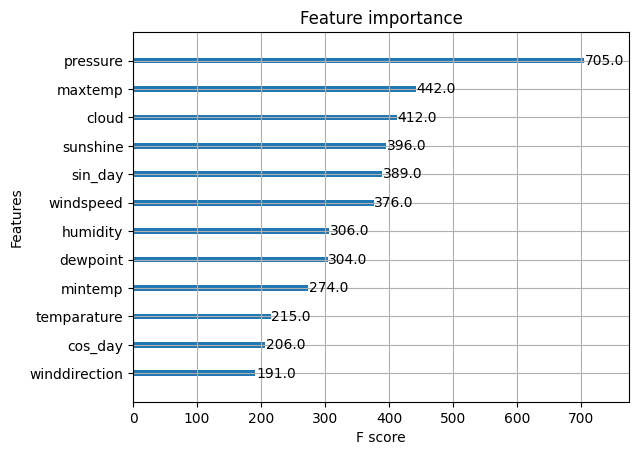

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Define features and target
X = train_data.drop(columns=['rainfall', 'id', 'day'])  # Replace 'target_column' with actual target
y = train_data['rainfall']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_model = xgb.XGBRegressor()  # Use XGBClassifier() for classification problems
xgb_model.fit(X_train, y_train)

# Plot feature importance
xgb.plot_importance(xgb_model)
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

In [ ]:
scaler = ColumnTransformer(
    transformers=[
        ('standard', StandardScaler(), [col for col in synthesized_data.columns if col not in ('rainfall', 'id', 'day', 'sin_day', 'cos_day')])
        ]
)

In [ ]:
X_scaled = scaler.fit_transform(synthesized_data.drop(columns=['day', 'rainfall']))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, synthesized_data['rainfall'], test_size=0.3, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((14000, 10), (6000, 10), (14000,), (6000,))

In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

In [ ]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 10, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0, 15),
    }

    model = lgb.LGBMClassifier(**params, verbose=-1)
    model.fit(X_train, y_train)

    y_preds = model.predict_proba(X_test)[:, 1]

    return roc_auc_score(y_test, y_preds)

study = optuna.create_study(direction="maximize",)
study.optimize(objective, n_trials=200, show_progress_bar=True)

print("Best Params:", study.best_params)

[I 2025-03-09 18:09:33,171] A new study created in memory with name: no-name-6f6c71e4-6212-49cc-bd5f-14eea805930d


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-03-09 18:09:33,233] Trial 0 finished with value: 0.8642685914491188 and parameters: {'max_depth': 12, 'num_leaves': 200, 'learning_rate': 0.13390056149898505, 'feature_fraction': 0.5019036501025218, 'bagging_fraction': 0.8662594160913112, 'bagging_freq': 1, 'min_child_samples': 76, 'lambda_l1': 0.07431528052525116, 'lambda_l2': 7.081567580324027e-05, 'min_gain_to_split': 5.156826574502582}. Best is trial 0 with value: 0.8642685914491188.
[I 2025-03-09 18:09:33,266] Trial 1 finished with value: 0.860606938700245 and parameters: {'max_depth': 7, 'num_leaves': 195, 'learning_rate': 0.07924003646546689, 'feature_fraction': 0.5585600003678701, 'bagging_fraction': 0.9793986593347648, 'bagging_freq': 3, 'min_child_samples': 18, 'lambda_l1': 2.315116839586413e-05, 'lambda_l2': 0.00261796865229234, 'min_gain_to_split': 13.293378128857043}. Best is trial 0 with value: 0.8642685914491188.
[I 2025-03-09 18:09:33,313] Trial 2 finished with value: 0.8629646215853112 and parameters: {'max_dep

In [ ]:
lgb_params ={'max_depth': 5, 'num_leaves': 44, 'learning_rate': 0.055326691492770974, 'feature_fraction': 0.6200807989972038, 'bagging_fraction': 0.4316634605881979, 'bagging_freq': 2, 'min_child_samples': 93, 'lambda_l1': 2.3673350189298768e-05, 'lambda_l2': 0.19064063015259883, 'min_gain_to_split': 2.3803363175850953}
lgb_model = lgb.LGBMClassifier(**lgb_params, verbose=-1)
lgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LGBMClassifier(bagging_fraction=0.4316634605881979, bagging_freq=2,
               feature_fraction=0.6200807989972038,
               lambda_l1=2.3673350189298768e-05, lambda_l2=0.19064063015259883,
               learning_rate=0.055326691492770974, max_depth=5,
               min_child_samples=93, min_gain_to_split=2.3803363175850953,
               num_leaves=44, verbose=-1)

In [ ]:
roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:, 1])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


0.7209112200963361

In [ ]:
cross_val_score(lgb_model, X, y, cv=5, scoring='roc_auc').mean()

0.8855780022446689

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000, step=100),
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10),
        "border_count": trial.suggest_int("border_count", 32, 64),
    }

    model = CatBoostClassifier(**params, loss_function="Logloss", eval_metric="AUC",
                               random_seed=42, verbose=0, gpu_ram_part=0.9)

    model.fit(X_train, y_train)

    y_preds = model.predict_proba(X_test)[:, 1]

    return roc_auc_score(y_test, y_preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200, show_progress_bar=True)

print("Best Parameters:", study.best_params)
print(f"Best ROC-AUC Score: {study.best_value:.4f}")

[I 2025-03-09 18:10:11,643] A new study created in memory with name: no-name-4726f74e-f7ca-488d-a7d6-da0a65186063


  0%|          | 0/200 [00:00<?, ?it/s]

<ipython-input-221-7d19d58fced0>:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
<ipython-input-221-7d19d58fced0>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10),


[I 2025-03-09 18:10:17,680] Trial 0 finished with value: 0.8557993730407525 and parameters: {'iterations': 900, 'learning_rate': 0.01966083599895928, 'depth': 9, 'l2_leaf_reg': 0.031209257429414147, 'border_count': 47}. Best is trial 0 with value: 0.8557993730407525.


<ipython-input-221-7d19d58fced0>:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
<ipython-input-221-7d19d58fced0>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10),


...

[I 2025-03-09 18:15:55,325] Trial 197 finished with value: 0.8713416401043176 and parameters: {'iterations': 900, 'learning_rate': 0.01828772458982666, 'depth': 3, 'l2_leaf_reg': 0.03834636344257455, 'border_count': 61}. Best is trial 171 with value: 0.8773214614999605.


<ipython-input-221-7d19d58fced0>:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
<ipython-input-221-7d19d58fced0>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10),


[I 2025-03-09 18:15:56,200] Trial 198 finished with value: 0.8741866652617158 and parameters: {'iterations': 800, 'learning_rate': 0.020210740544327182, 'depth': 3, 'l2_leaf_reg': 0.049320857067195474, 'border_count': 62}. Best is trial 171 with value: 0.8773214614999605.


<ipython-input-221-7d19d58fced0>:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
<ipython-input-221-7d19d58fced0>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10),


[I 2025-03-09 18:15:57,734] Trial 199 finished with value: 0.8641500487342272 and parameters: {'iterations': 900, 'learning_rate': 0.017419315541713474, 'depth': 6, 'l2_leaf_reg': 0.07985905857317684, 'border_count': 61}. Best is trial 171 with value: 0.8773214614999605.
Best Parameters: {'iterations': 900, 'learning_rate': 0.01860125274109229, 'depth': 3, 'l2_leaf_reg': 0.12416524287824111, 'border_count': 62}
Best ROC-AUC Score: 0.8773


In [ ]:
cat_params =  {'iterations': 900, 'learning_rate': 0.01860125274109229, 'depth': 3, 'l2_leaf_reg': 0.12416524287824111, 'border_count': 62}
cat_model = catboost.CatBoostClassifier(**cat_params, loss_function="Logloss", eval_metric="AUC",
                               random_seed=42, verbose=0, gpu_ram_part=0.9)
cat_model.fit(X_train, y_train)

In [ ]:
roc_auc_score(y_test, cat_model.predict_proba(X_test)[:, 1])

0.8773214614999605

In [ ]:
cross_val_score(cat_model, X, y, cv=5, scoring='roc_auc').mean()

0.8907407407407408

In [ ]:
from catboost import CatBoostClassifier
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score

def ctb_evaluate(iterations, depth, learning_rate, l2_leaf_reg):
    params = {
        'iterations': int(iterations),
        'depth': int(depth),
        'learning_rate': learning_rate,
        'l2_leaf_reg': l2_leaf_reg,
        'loss_function': 'Logloss',  # For binary classification
        'eval_metric': 'AUC',
        'verbose': False,
        'random_state': 42,
        'allow_writing_files': False
    }

    model = CatBoostClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    return score

# Hyperparameter bounds
pbounds = {
    'iterations': (100, 2000),      # Equivalent to n_estimators
    'depth': (4, 12),               # Tree depth
    'learning_rate': (0.01, 0.3),   # Step size shrinkage
    'l2_leaf_reg': (1, 30)          # Regularization
}

# Initialize optimizer
optimizer = BayesianOptimization(
    f=ctb_evaluate,
    pbounds=pbounds,
    random_state=42,
)

# Run optimization
optimizer.maximize(init_points=5, n_iter=25)

# Best results
print(f"Best parameters: {optimizer.max['params']}")
print(f"Best AUC score: {optimizer.max['target']:.4f}")

|   iter    |  target   |   depth   | iterat... | l2_lea... | learni... |
-------------------------------------------------------------------------
| 1         | 0.8817    | 6.996     | 1.906e+03 | 22.23     | 0.1836    |
| 2         | 0.8778    | 5.248     | 396.4     | 2.684     | 0.2612    |
| 3         | 0.8876    | 8.809     | 1.445e+03 | 1.597     | 0.2913    |
| 4         | 0.8921    | 10.66     | 503.4     | 6.273     | 0.06319   |
| 5         | 0.8859    | 6.434     | 1.097e+03 | 13.53     | 0.09446   |
| 6         | 0.8908    | 10.16     | 1.443e+03 | 2.164     | 0.1685    |
| 7         | 0.8849    | 8.398     | 506.4     | 9.748     | 0.2089    |
| 8         | 0.89      | 11.47     | 503.6     | 3.647     | 0.1569    |
| 9         | 0.8933    | 7.724     | 501.2     | 6.464     | 0.06661   |
| 10        | 0.8906    | 9.172     | 497.7     | 10.16     | 0.1338    |
| 11        | 0.8832    | 6.226     | 497.1     | 4.204     | 0.2569    |
| 12        | 0.8867    | 4.923     | 

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),  # Similar to iterations in CatBoost
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 12),                      # Similar to depth in CatBoost
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-3, 10),        # Similar to l2_leaf_reg in CatBoost
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),                # Similar to bagging_fraction in CatBoost
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),  # Similar to feature_fraction in CatBoost
        "objective": "binary:logistic",                                         # For binary classification
        "eval_metric": "auc",                                                  # Metric to optimize
        "random_state": 42,                                                    # For reproducibility
        "n_jobs": -1,                                                          # Use all available cores
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    y_preds = model.predict_proba(X_test)[:, 1]

    return roc_auc_score(y_test, y_preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200, show_progress_bar=True)

print("Best Parameters:", study.best_params)

[I 2025-03-09 18:18:34,205] A new study created in memory with name: no-name-492d6aba-01ab-438c-8bf7-e3769ed09c37


  0%|          | 0/200 [00:00<?, ?it/s]

<ipython-input-226-a3b1dbed9246>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
<ipython-input-226-a3b1dbed9246>:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-3, 10),        # Similar to l2_leaf_reg in CatBoost


[I 2025-03-09 18:18:35,408] Trial 0 finished with value: 0.843523616343089 and parameters: {'n_estimators': 900, 'learning_rate': 0.10941169993138036, 'max_depth': 12, 'reg_lambda': 2.7813992616267202, 'subsample': 0.9229942707439651, 'colsample_bytree': 0.8751552246289016}. Best is trial 0 with value: 0.843523616343089.


<ipython-input-226-a3b1dbed9246>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
<ipython-input-226-a3b1dbed9246>:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-3, 10),        # Similar to l2_leaf_reg in CatBoost


...

[I 2025-03-09 18:20:40,014] Trial 197 finished with value: 0.8713679829298491 and parameters: {'n_estimators': 700, 'learning_rate': 0.015098253442455795, 'max_depth': 3, 'reg_lambda': 8.374964688219277, 'subsample': 0.52308191786095, 'colsample_bytree': 0.5292584002973919}. Best is trial 192 with value: 0.8734490661468349.


<ipython-input-226-a3b1dbed9246>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
<ipython-input-226-a3b1dbed9246>:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-3, 10),        # Similar to l2_leaf_reg in CatBoost


[I 2025-03-09 18:20:40,418] Trial 198 finished with value: 0.8725797529042965 and parameters: {'n_estimators': 700, 'learning_rate': 0.013547327575980308, 'max_depth': 3, 'reg_lambda': 7.8039419402214625, 'subsample': 0.51510742868075, 'colsample_bytree': 0.5412727692603375}. Best is trial 192 with value: 0.8734490661468349.


<ipython-input-226-a3b1dbed9246>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
<ipython-input-226-a3b1dbed9246>:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-3, 10),        # Similar to l2_leaf_reg in CatBoost


[I 2025-03-09 18:20:40,813] Trial 199 finished with value: 0.868601986249045 and parameters: {'n_estimators': 700, 'learning_rate': 0.014061868260461208, 'max_depth': 3, 'reg_lambda': 0.33643455974399855, 'subsample': 0.5356707764083538, 'colsample_bytree': 0.5442891341523712}. Best is trial 192 with value: 0.8734490661468349.
Best Parameters: {'n_estimators': 700, 'learning_rate': 0.0136541986798133, 'max_depth': 3, 'reg_lambda': 7.224598083444587, 'subsample': 0.5065105885118979, 'colsample_bytree': 0.5437416047624931}


In [ ]:
xgb_params = {'n_estimators': 700, 'learning_rate': 0.0136541986798133, 'max_depth': 3, 'reg_lambda': 7.224598083444587, 'subsample': 0.5065105885118979, 'colsample_bytree': 0.5437416047624931}
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5437416047624931, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.0136541986798133,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=700, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

0.8728695239851426

In [ ]:
cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='roc_auc').mean()

0.9019275429470033

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression()

stacking_model = StackingClassifier(
    estimators=[
        ('lgb', lgb_model),
        ('cat', cat_model),
        ('xgb', xgb_model)],
    final_estimator=meta_model
)

stacking_model.fit(X, y)

StackingClassifier(estimators=[('lgb',
                                LGBMClassifier(bagging_fraction=0.4316634605881979,
                                               bagging_freq=2,
                                               feature_fraction=0.6200807989972038,
                                               lambda_l1=2.3673350189298768e-05,
                                               lambda_l2=0.19064063015259883,
                                               learning_rate=0.055326691492770974,
                                               max_depth=5,
                                               min_child_samples=93,
                                               min_gain_to_split=2.3803363175850953,
                                               num_leaves=44, verbose=-1)),
                               ('cat',
                                <catboos...
                                              interaction_constraints=None,
                                              learning_rate=0.0136541986798133,
                                              max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=3,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=700, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=None, ...))],
                   final_estimator=LogisticRegression())

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.impute import KNNImputer

final_model = Pipeline([
    ('Imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('model', stacking_model)
])

final_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Pipeline(steps=[('Imputer', KNNImputer()), ('scaler', StandardScaler()),
                ('model',
                 StackingClassifier(estimators=[('lgb',
                                                 LGBMClassifier(bagging_fraction=0.4316634605881979,
                                                                bagging_freq=2,
                                                                feature_fraction=0.6200807989972038,
                                                                lambda_l1=2.3673350189298768e-05,
                                                                lambda_l2=0.19064063015259883,
                                                                learning_rate=0.055326691492770974,
                                                                max_depth=5,
                                                                min_child_samples=93,
                                                                m...
                                                               interaction_constraints=None,
                                                               learning_rate=0.0136541986798133,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=3,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=700,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               random_state=None, ...))],
                                    final_estimator=LogisticRegression()))])

In [ ]:
test_point = X_test.iloc[10].values.reshape(1, -1)
test_point

array([[ 1.01010000e+03,  3.06000000e+01,  2.51000000e+01,
         8.90000000e+01,  8.90000000e+01,  2.00000000e+00,
         2.14000000e+01,  9.48361580e-01, -3.17191289e-01]])

In [ ]:
final_model.predict_proba(np.array([[ 1.01010000e+03,  3.06000000e+01,  2.51000000e+01,
         8.90000000e+01,  8.90000000e+01,  np.nan,
         2.14000000e+01,  9.48361580e-01, -3.17191289e-01]]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNNImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[0.05258812, 0.94741188]])

In [ ]:
import joblib

# Save the model
joblib.dump(final_model, "model.pkl")
print("Model saved successfully!")


Model saved successfully!


In [ ]:
roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


0.8787439740786597

In [ ]:
roc_auc_score(y_test, stacking_model.predict_proba(X_test)[:, 1])

0.9191275256183978

In [ ]:
predictions = stacking_model.predict_proba(X_eval)[:, 1]

In [ ]:
submission = pd.DataFrame({'id': test_data['id'], 'rainfall': predictions.flatten()})
submission.to_csv('submission.csv', index=False)

In [ ]:
submission_massage = 'Ensemble Solution'
!kaggle competitions submit -c playground-series-s5e3 -f submission.csv -m "{submission_massage}"

100% 11.0k/11.0k [00:00<00:00, 34.6kB/s]
Successfully submitted to Binary Prediction with a Rainfall Dataset

In [ ]:
X.columns

Index(['pressure', 'maxtemp', 'dewpoint', 'humidity', 'cloud', 'sunshine',
       'windspeed', 'sin_day', 'cos_day'],
      dtype='object')

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(400, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.2))
model.add(Dense(300, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(80, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(60, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(40, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_121 (Dense)                    │ (None, 400)                 │           5,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_71 (Dropout)                 │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_122 (Dense)                    │ (None, 300)                 │         120,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_72 (Dropout)                 │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_123 (Dense)                    │ (None, 200)                 │          60,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_73 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_124 (Dense)                    │ (None, 100)                 │          20,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_74 (Dropout)                 │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_125 (Dense)                    │ (None, 80)                  │           8,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_75 (Dropout)                 │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_126 (Dense)                    │ (None, 60)                  │           4,860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_76 (Dropout)                 │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_127 (Dense)                    │ (None, 40)                  │           2,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_77 (Dropout)                 │ (None, 40)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_128 (Dense)                    │ (None, 1)                   │              41 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 221,221 (864.14 KB)

 Trainable params: 221,221 (864.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

In [ ]:
X, y = train_data.drop(columns=['rainfall', 'id', 'day']), train_data['rainfall']

In [ ]:
history = model.fit(X, y, epochs=1000, batch_size=32, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)], verbose=1)

Epoch 1/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - AUC: 0.5029 - loss: 4.2092 - val_AUC: 0.5051 - val_loss: 0.5351
Epoch 2/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4966 - loss: 0.9629 - val_AUC: 0.4018 - val_loss: 0.5828
Epoch 3/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.4964 - loss: 0.6935 - val_AUC: 0.4516 - val_loss: 0.5712
Epoch 4/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - AUC: 0.5149 - loss: 0.6531 - val_AUC: 0.3071 - val_loss: 0.6236
Epoch 5/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - AUC: 0.4848 - loss: 0.6480 - val_AUC: 0.5099 - val_loss: 0.5795
Epoch 6/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.4629 - loss: 0.6486 - val_AUC: 0.2738 - val_loss: 0.6260
Epoch 7/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - AUC: 0.4931 - loss: 0.5982 - val_AUC: 0.6621 - val_loss: 0.6000
Epoch 8/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.5092 - loss: 0.6272 - val_AUC: 0.6123 - val_loss: 0.5774
Epoch 9/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/

In [ ]:
from sklearn.metrics import roc_auc_score
predictions = model.predict(X_eval).flatten()
roc_auc_score(y_eval, predictions)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


0.8704723268617791

In [ ]:
X_test = test_data.drop(columns=['id', 'day'])

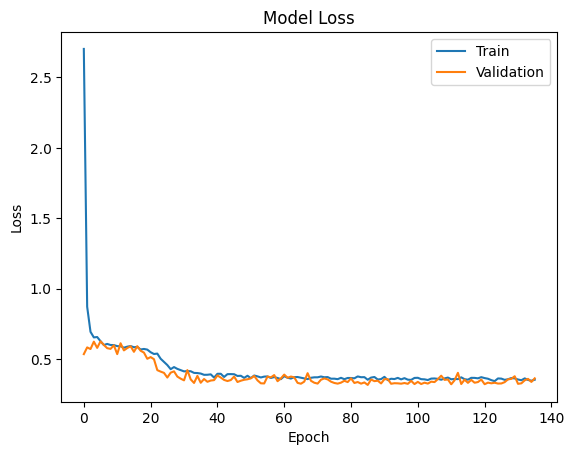

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

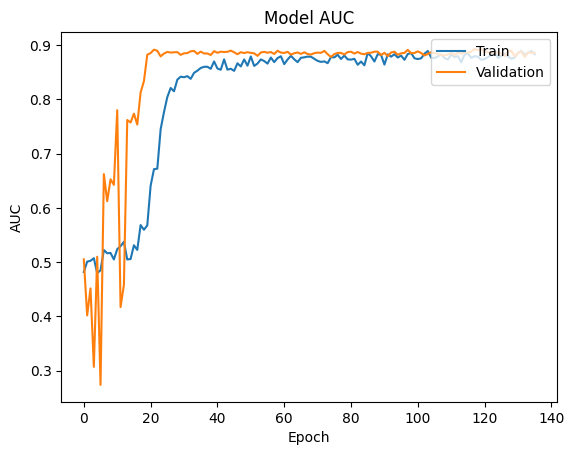

In [ ]:
plt.plot(history.history['AUC'])
plt.plot(history.history['val_AUC'])
plt.title('Model AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

In [ ]:
from sklearn.metrics import roc_auc_score
predictions = model.predict(X_eval)
roc_auc_score(y_eval, predictions)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


0.8704723268617791

In [ ]:
predictions = model.predict(X_test).flatten()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
predictions = np.nan_to_num(predictions, nan=0)

In [ ]:
predictions

array([0.97403693, 0.9785095 , 0.9292996 , 0.17817856, 0.12702674,
       0.8942695 , 0.9256561 , 0.96742135, 0.95376974, 0.7093978 ,
       0.9772555 , 0.15506369, 0.9771029 , 0.94754183, 0.27660713,
       0.01782886, 0.8850136 , 0.71427816, 0.16358314, 0.01474451,
       0.20048867, 0.24227405, 0.8663286 , 0.97727746, 0.8890322 ,
       0.43021315, 0.03063857, 0.97416306, 0.9233866 , 0.45107704,
       0.94617677, 0.95115393, 0.8693062 , 0.96652085, 0.8749996 ,
       0.91438943, 0.32795292, 0.92095315, 0.83773816, 0.8847959 ,
       0.8901296 , 0.896835  , 0.18460317, 0.92082715, 0.94615215,
       0.30606505, 0.25427908, 0.96570736, 0.3296453 , 0.8511265 ,
       0.9585535 , 0.9760774 , 0.9772588 , 0.9601036 , 0.9716263 ,
       0.97152984, 0.94058084, 0.9419509 , 0.93906397, 0.95824003,
       0.878638  , 0.96518844, 0.96538067, 0.8686846 , 0.45925397,
       0.375889  , 0.20824702, 0.88500553, 0.88684905, 0.12343221,
       0.97983205, 0.9232516 , 0.9487503 , 0.9584117 , 0.96762